## UNIT - 3 ~ 4 MARKS
- `pd.get_dummies`
- `np.where`
- arithmetic operations
- train_test_split

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data,columns=iris.feature_names)
print(df)
df['target'] = iris.target
df['species'] = df['target'].map(
{
    0:'setosa',
    1:'versicolor',
    2:'virginica'
}
)
df.head(1)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa


In [3]:
df.shape

(150, 6)

## pd.get_dummies (One hot encoding)
- This method converts categorical columns to boolean(numerical columns)
- The purpose is to facilitate ML Analysis

In [6]:
pd.get_dummies(df,columns=['species'],drop_first=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,0,0,0
1,4.9,3.0,1.4,0.2,0,0,0
2,4.7,3.2,1.3,0.2,0,0,0
3,4.6,3.1,1.5,0.2,0,0,0
4,5.0,3.6,1.4,0.2,0,0,0
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,0,1
146,6.3,2.5,5.0,1.9,2,0,1
147,6.5,3.0,5.2,2.0,2,0,1
148,6.2,3.4,5.4,2.3,2,0,1


## `np.where`
- Condition based filtering of dataframe columns

In [7]:
df.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa


In [8]:
df['size'] = np.where(df["sepal length (cm)"] > 6.5, 'Large',
             np.where(df["sepal length (cm)"] > 5.5, 'Medium',
             "Small"))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,size
0,5.1,3.5,1.4,0.2,0,setosa,Small
1,4.9,3.0,1.4,0.2,0,setosa,Small
2,4.7,3.2,1.3,0.2,0,setosa,Small
3,4.6,3.1,1.5,0.2,0,setosa,Small
4,5.0,3.6,1.4,0.2,0,setosa,Small


In [ ]:
print(df.to_string())

### Export to csv

In [10]:
df.to_csv("Myiris.csv")

## PB 190 /  191 / 192
```
You've been given a dataset with apartment area and price information. There's a noticeable non-linear relationship between area and price. To address this you intend to categorize them into 'High', 'Medium', and 'Low' groups. Prices above 3,000,000 are 'High', below `$2,000,000` are 'Low', and between `$2,000,000` and `$3,000,000` are 'Medium'. Write a code to achieve this assuming that dataset has two columns named area and price.
```

In [ ]:
import pandas as pd
import numpy as np
# Assuming the df is the dataframe containing price column
df['pricegroup'] = np.where(df["price"] > 3000000, 'High',
             np.where(df["price"] > 2000000, 'Medium',
             "Low"))
print(df)

## Arithmetic operations

In [11]:
df.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,size
0,5.1,3.5,1.4,0.2,0,setosa,Small


In [12]:
df["sepalsum"] = df["sepal length (cm)"] + df["sepal width (cm)"]

In [13]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,size,sepalsum
0,5.1,3.5,1.4,0.2,0,setosa,Small,8.6
1,4.9,3.0,1.4,0.2,0,setosa,Small,7.9
2,4.7,3.2,1.3,0.2,0,setosa,Small,7.9
3,4.6,3.1,1.5,0.2,0,setosa,Small,7.7
4,5.0,3.6,1.4,0.2,0,setosa,Small,8.6
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica,Large,9.7
146,6.3,2.5,5.0,1.9,2,virginica,Medium,8.8
147,6.5,3.0,5.2,2.0,2,virginica,Medium,9.5
148,6.2,3.4,5.4,2.3,2,virginica,Medium,9.6


## train_test_split
- This is an sklearn method used to split the data into training and testing data for machine learning analysis

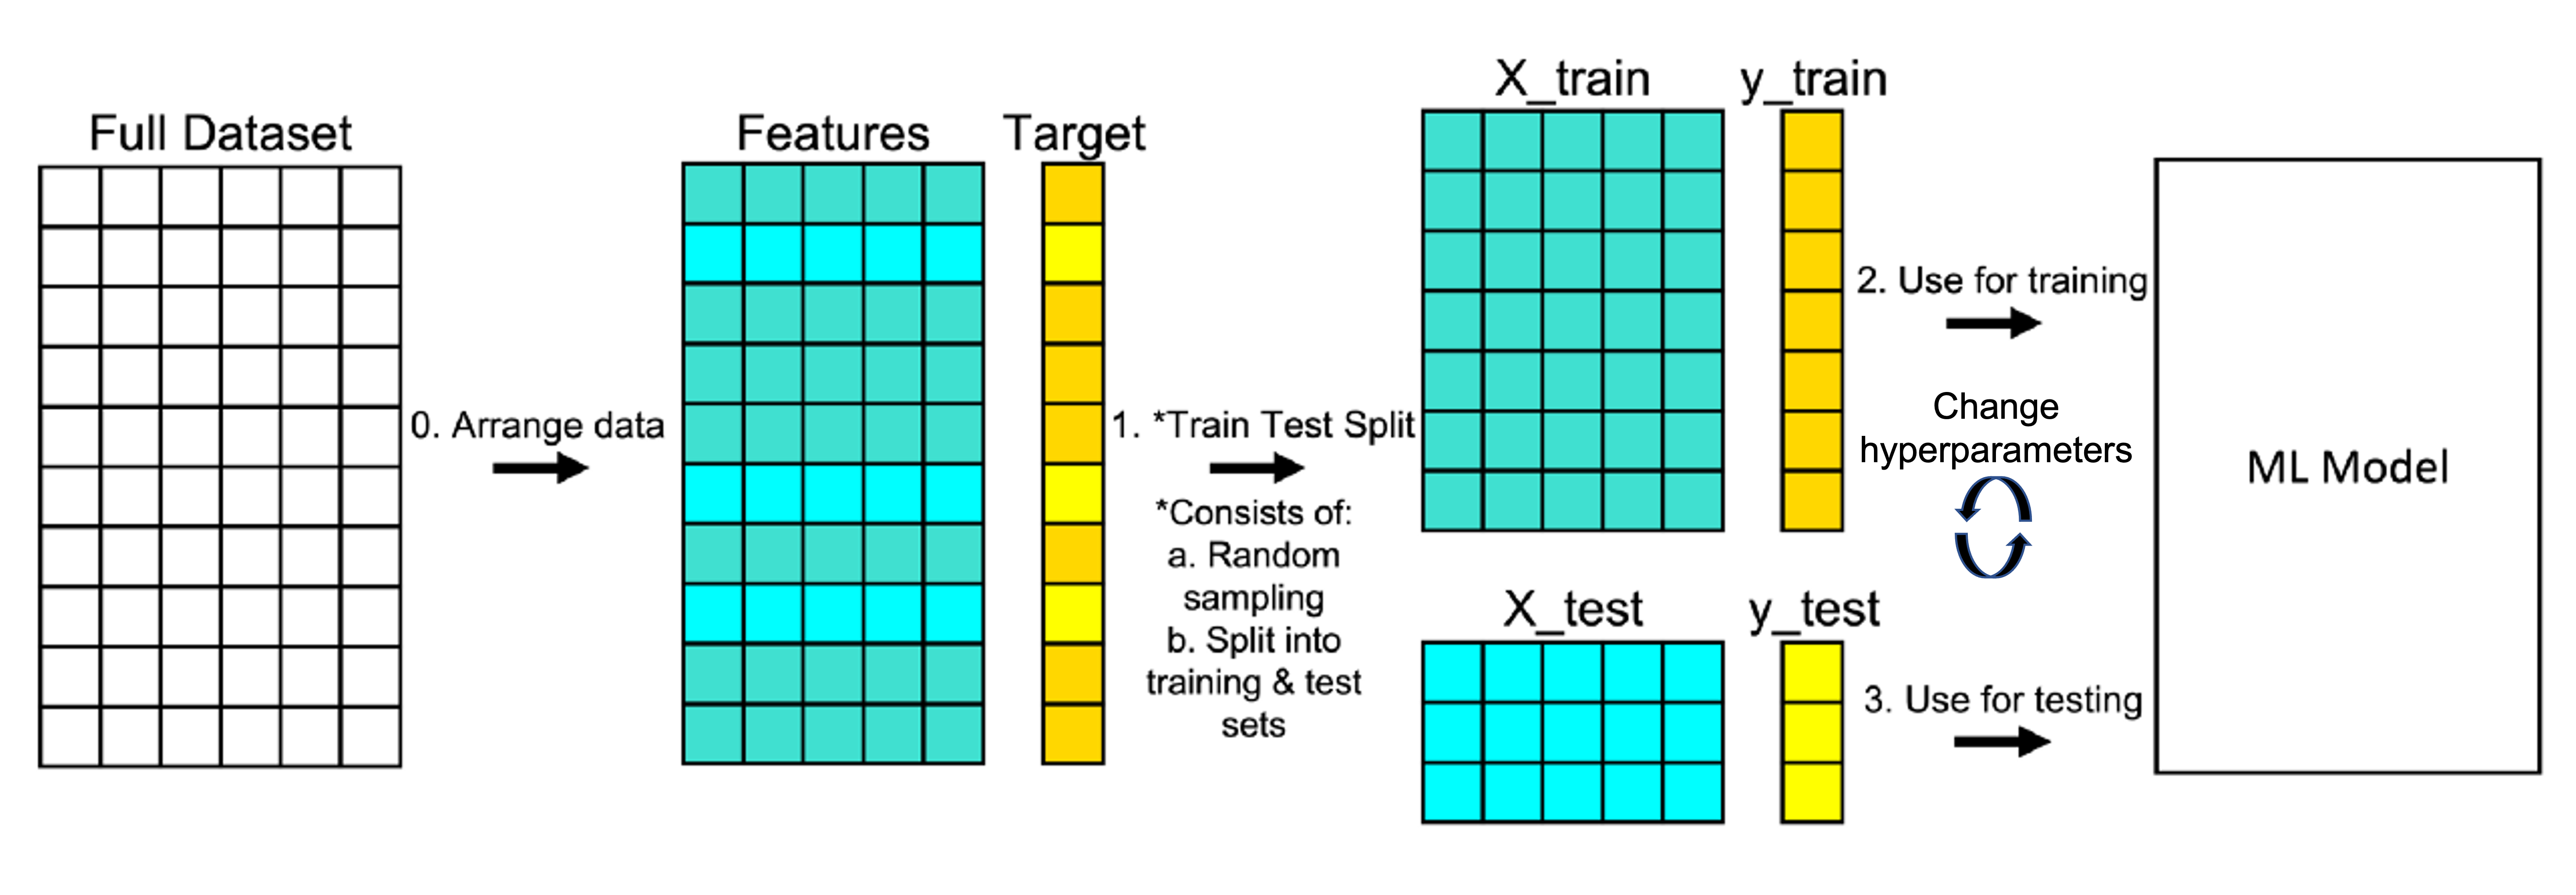

In [14]:
from sklearn.model_selection import train_test_split
x = df[iris.feature_names]
y = df["target"]
x_train,x_test,y_train,y_test = train_test_split(
x,y,test_size = 0.2,random_state = 42
)

In [15]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)
